# Understand & Load Data

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings
warnings.filterwarnings('ignore')

In [2]:
values_df = pd.read_csv('values.csv')
labels_df = pd.read_csv('labels.csv')

In [3]:
df = pd.merge(values_df, labels_df, on='patient_id')

In [4]:
df.head()

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 15 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   patient_id                            180 non-null    object 
 1   slope_of_peak_exercise_st_segment     180 non-null    int64  
 2   thal                                  180 non-null    object 
 3   resting_blood_pressure                180 non-null    int64  
 4   chest_pain_type                       180 non-null    int64  
 5   num_major_vessels                     180 non-null    int64  
 6   fasting_blood_sugar_gt_120_mg_per_dl  180 non-null    int64  
 7   resting_ekg_results                   180 non-null    int64  
 8   serum_cholesterol_mg_per_dl           180 non-null    int64  
 9   oldpeak_eq_st_depression              180 non-null    float64
 10  sex                                   180 non-null    int64  
 11  age                

In [6]:
df.describe()

,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,1.550000,131.311111,3.155556,0.694444,0.161111,1.050000,249.211111,1.010000,0.688889,54.811111,149.483333,0.316667,0.444444
std,0.618838,17.010443,0.938454,0.969347,0.368659,0.998742,52.717969,1.121357,0.464239,9.334737,22.063513,0.466474,0.498290
min,1.000000,94.000000,1.000000,0.000000,0.000000,0.000000,126.000000,0.000000,0.000000,29.000000,96.000000,0.000000,0.000000
25%,1.000000,120.000000,3.000000,0.000000,0.000000,0.000000,213.750000,0.000000,0.000000,48.000000,132.000000,0.000000,0.000000
50%,1.000000,130.000000,3.000000,0.000000,0.000000,2.000000,245.500000,0.800000,1.000000,55.000000,152.000000,0.000000,0.000000
75%,2.000000,140.000000,4.000000,1.000000,0.000000,2.000000,281.250000,1.600000,1.000000,62.000000,166.250000,1.000000,1.000000
max,3.000000,180.000000,4.000000,3.000000,1.000000,2.000000,564.000000,6.200000,1.000000,77.000000,202.000000,1.000000,1.000000


In [7]:
df.isnull().sum()

patient_id                              0
slope_of_peak_exercise_st_segment       0
thal                                    0
resting_blood_pressure                  0
chest_pain_type                         0
num_major_vessels                       0
fasting_blood_sugar_gt_120_mg_per_dl    0
resting_ekg_results                     0
serum_cholesterol_mg_per_dl             0
oldpeak_eq_st_depression                0
sex                                     0
age                                     0
max_heart_rate_achieved                 0
exercise_induced_angina                 0
heart_disease_present                   0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.nunique()

patient_id                              180
slope_of_peak_exercise_st_segment         3
thal                                      3
resting_blood_pressure                   36
chest_pain_type                           4
num_major_vessels                         4
fasting_blood_sugar_gt_120_mg_per_dl      2
resting_ekg_results                       3
serum_cholesterol_mg_per_dl             118
oldpeak_eq_st_depression                 34
sex                                       2
age                                      40
max_heart_rate_achieved                  73
exercise_induced_angina                   2
heart_disease_present                     2
dtype: int64

In [10]:
df["heart_disease_present"].value_counts()

heart_disease_present
0    100
1     80
Name: count, dtype: int64

In [11]:
df["heart_disease_present"].value_counts(normalize=True) * 100

heart_disease_present
0    55.555556
1    44.444444
Name: proportion, dtype: float64

# Exploratory Data Analysis

# Target Variable Analysis

In [12]:
print(df["heart_disease_present"].value_counts())

print("\nPercentage distribution:")
print(df["heart_disease_present"].value_counts(normalize=True) * 100)

heart_disease_present
0    100
1     80
Name: count, dtype: int64

Percentage distribution:
heart_disease_present
0    55.555556
1    44.444444
Name: proportion, dtype: float64


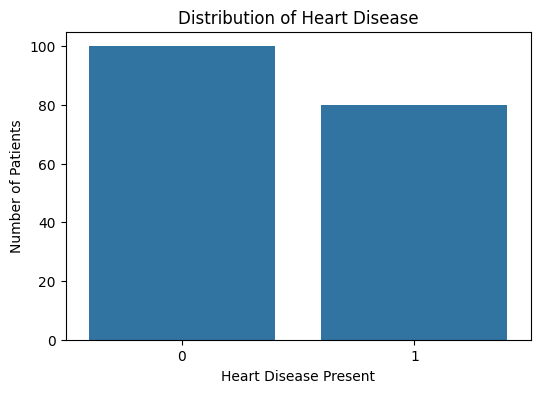

In [13]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df,x="heart_disease_present")

plt.title("Distribution of Heart Disease")
plt.xlabel("Heart Disease Present")
plt.ylabel("Number of Patients")
plt.show()

# Numerical Feature Analysis

In [14]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns

print(numerical_cols)

Index(['slope_of_peak_exercise_st_segment', 'resting_blood_pressure',
       'chest_pain_type', 'num_major_vessels',
       'fasting_blood_sugar_gt_120_mg_per_dl', 'resting_ekg_results',
       'serum_cholesterol_mg_per_dl', 'oldpeak_eq_st_depression', 'sex', 'age',
       'max_heart_rate_achieved', 'exercise_induced_angina',
       'heart_disease_present'],
      dtype='object')


In [15]:
numerical_features = [
    col for col in numerical_cols
    if col != "heart_disease_present"
]

print("Numerical Features:")
print(numerical_features)

Numerical Features:
['slope_of_peak_exercise_st_segment', 'resting_blood_pressure', 'chest_pain_type', 'num_major_vessels', 'fasting_blood_sugar_gt_120_mg_per_dl', 'resting_ekg_results', 'serum_cholesterol_mg_per_dl', 'oldpeak_eq_st_depression', 'sex', 'age', 'max_heart_rate_achieved', 'exercise_induced_angina']


# Statistical Summary

In [16]:
df[numerical_features].describe().T

,count,mean,std,min,25%,50%,75%,max
slope_of_peak_exercise_st_segment,180.0,1.550000,0.618838,1.0,1.00,1.0,2.00,3.0
resting_blood_pressure,180.0,131.311111,17.010443,94.0,120.00,130.0,140.00,180.0
chest_pain_type,180.0,3.155556,0.938454,1.0,3.00,3.0,4.00,4.0
num_major_vessels,180.0,0.694444,0.969347,0.0,0.00,0.0,1.00,3.0
fasting_blood_sugar_gt_120_mg_per_dl,180.0,0.161111,0.368659,0.0,0.00,0.0,0.00,1.0
resting_ekg_results,180.0,1.050000,0.998742,0.0,0.00,2.0,2.00,2.0
serum_cholesterol_mg_per_dl,180.0,249.211111,52.717969,126.0,213.75,245.5,281.25,564.0
oldpeak_eq_st_depression,180.0,1.010000,1.121357,0.0,0.00,0.8,1.60,6.2
sex,180.0,0.688889,0.464239,0.0,0.00,1.0,1.00,1.0
age,180.0,54.811111,9.334737,29.0,48.00,55.0,62.00,77.0


# Distribution of Numerical Features

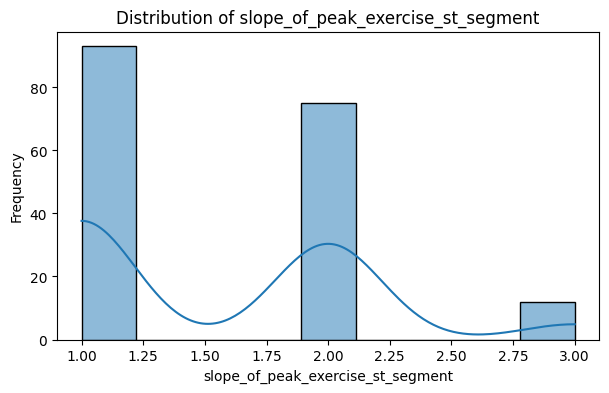

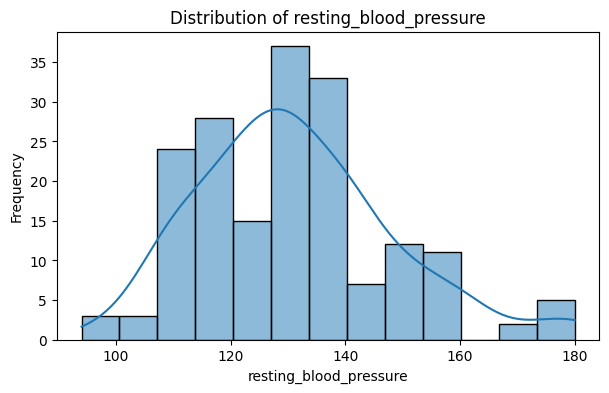

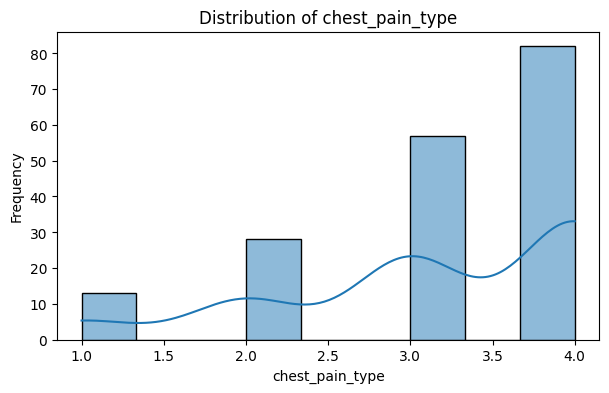

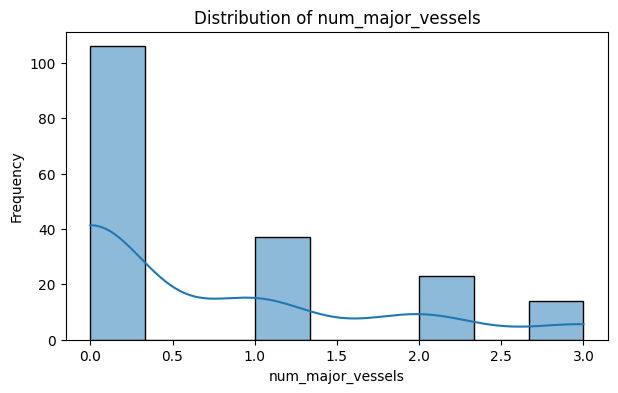

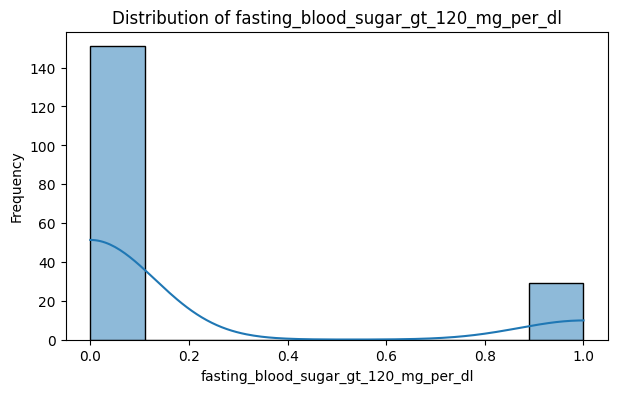

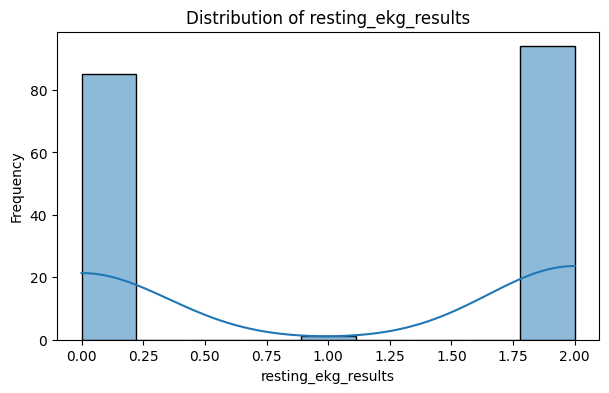

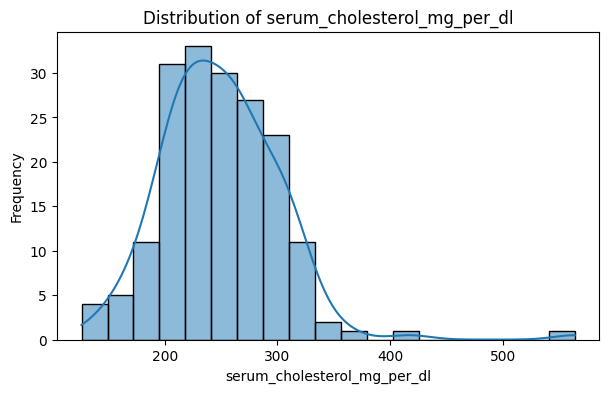

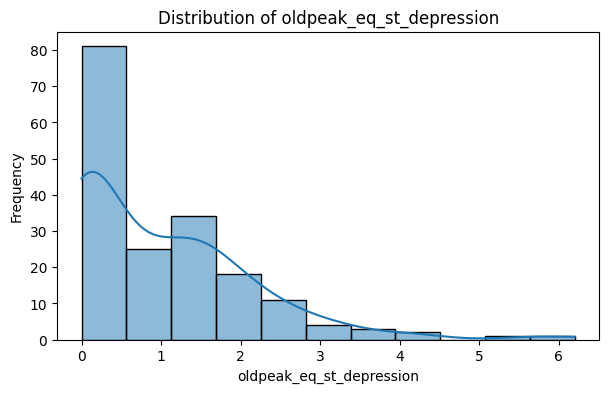

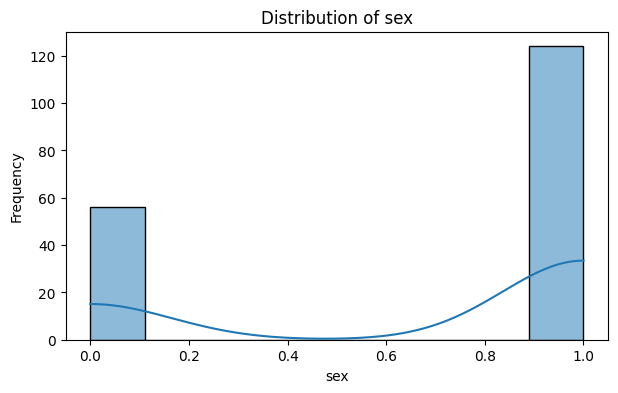

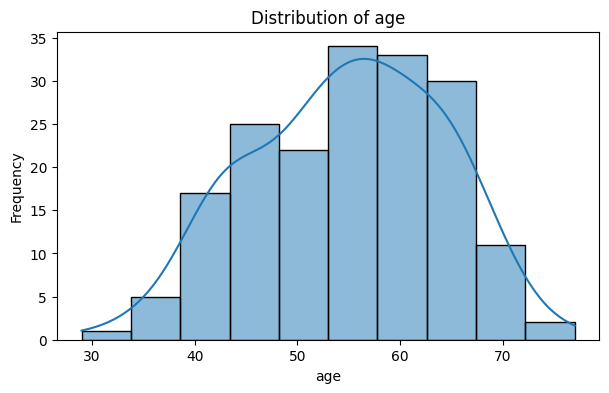

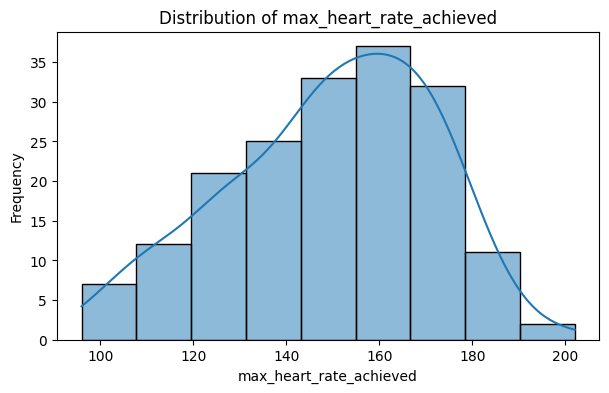

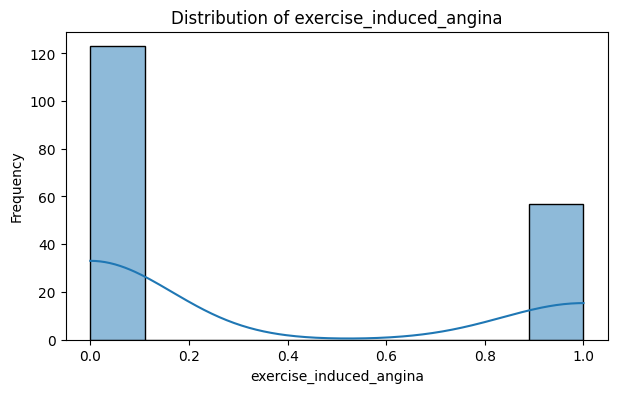

In [17]:
for col in numerical_features:

    plt.figure(figsize=(7, 4))

    sns.histplot(data=df,x=col,kde=True)

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.show()

# Categorical Feature Analysis

In [18]:
print(df["thal"].value_counts())

thal
normal               98
reversible_defect    74
fixed_defect          8
Name: count, dtype: int64


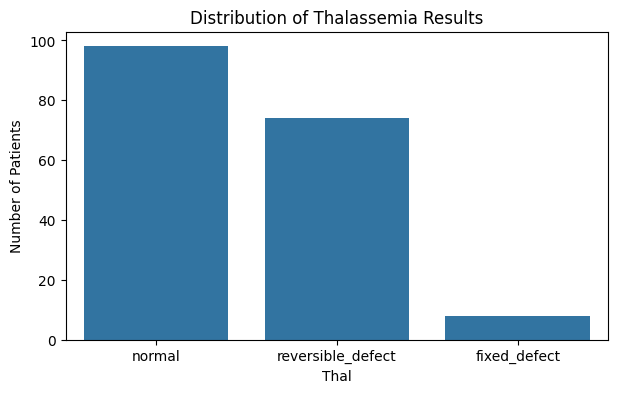

In [19]:
plt.figure(figsize=(7, 4))

sns.countplot(data=df,x="thal")

plt.title("Distribution of Thalassemia Results")
plt.xlabel("Thal")
plt.ylabel("Number of Patients")

plt.show()

# Outlier Analysis

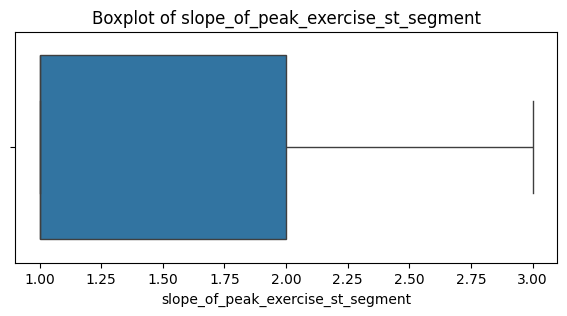

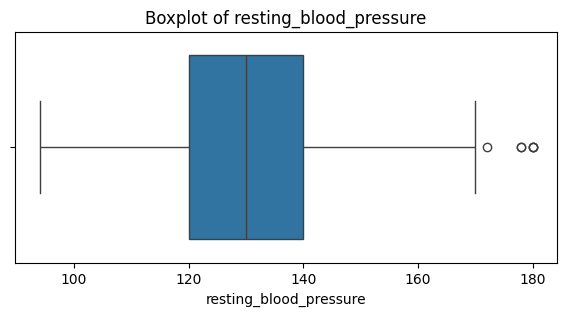

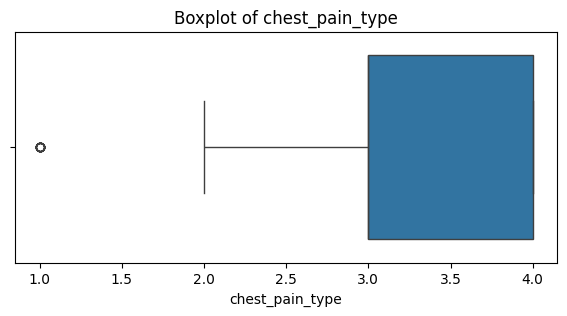

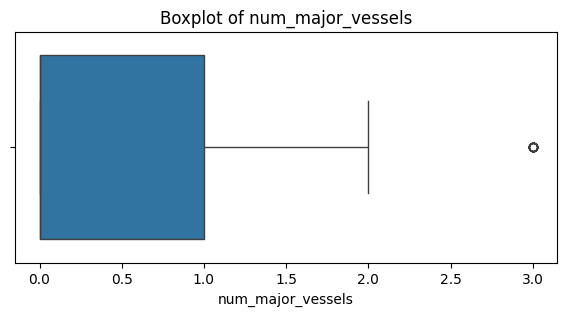

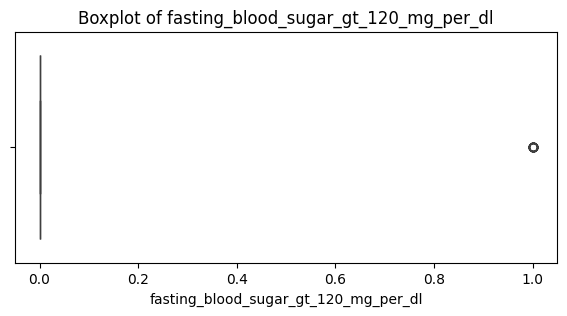

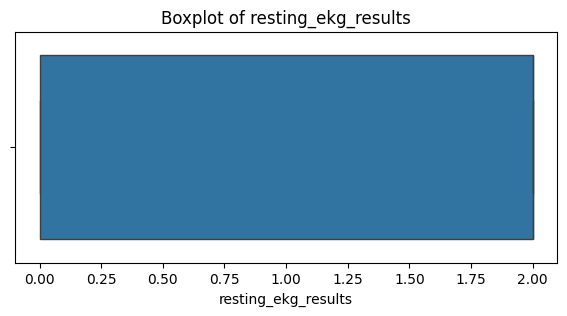

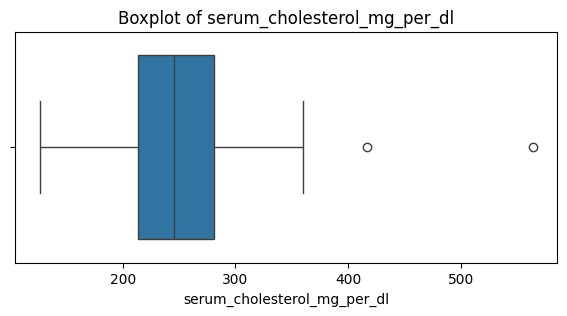

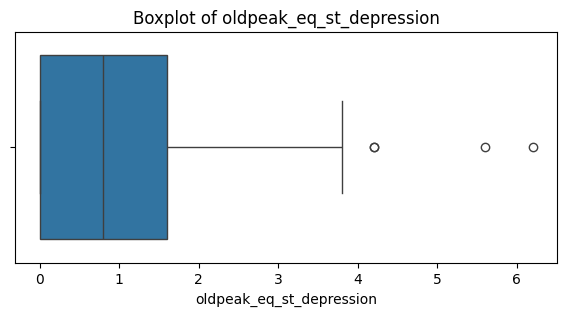

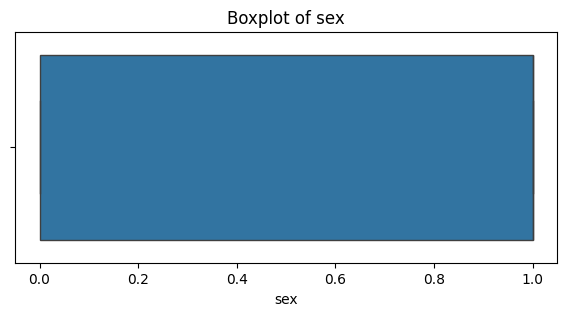

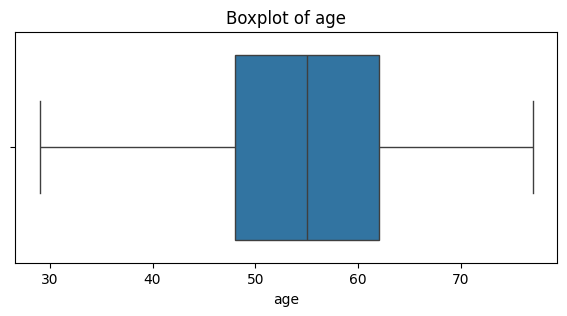

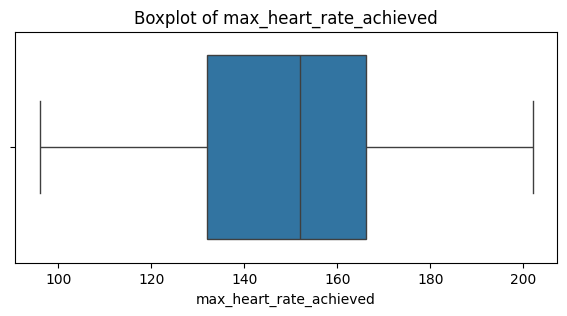

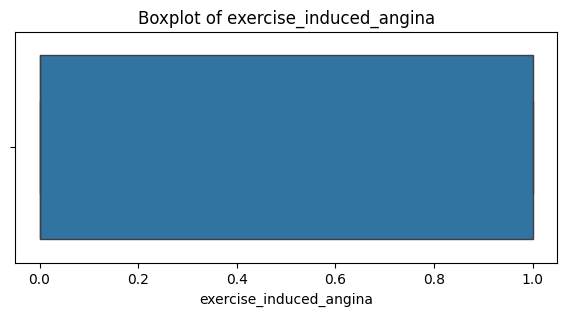

In [20]:
for col in numerical_features:

    plt.figure(figsize=(7, 3))

    sns.boxplot(x=df[col])

    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)

    plt.show()

In [21]:
for col in numerical_features:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    print(f"{col}: {len(outliers)} outliers")

slope_of_peak_exercise_st_segment: 0 outliers
resting_blood_pressure: 6 outliers
chest_pain_type: 13 outliers
num_major_vessels: 14 outliers
fasting_blood_sugar_gt_120_mg_per_dl: 29 outliers
resting_ekg_results: 0 outliers
serum_cholesterol_mg_per_dl: 2 outliers
oldpeak_eq_st_depression: 4 outliers
sex: 0 outliers
age: 0 outliers
max_heart_rate_achieved: 0 outliers
exercise_induced_angina: 0 outliers


# Correlation Analysis

In [22]:
correlation_matrix = df[numerical_features + ["heart_disease_present"]].corr()

correlation_matrix

,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
slope_of_peak_exercise_st_segment,1.000000,0.098287,0.121207,0.076832,0.050199,0.172191,-0.032348,0.615948,0.093340,0.169918,-0.418102,0.225459,0.344224
resting_blood_pressure,0.098287,1.000000,-0.029296,0.042388,0.166570,0.078986,0.144881,0.219026,-0.055589,0.284402,-0.017521,0.123397,0.078506
chest_pain_type,0.121207,-0.029296,1.000000,0.249061,-0.088992,0.033379,0.061213,0.080799,0.086057,0.085001,-0.301792,0.346266,0.412829
num_major_vessels,0.076832,0.042388,0.249061,1.000000,0.169792,0.096656,0.098348,0.214062,0.073107,0.347355,-0.275687,0.153407,0.421519
fasting_blood_sugar_gt_120_mg_per_dl,0.050199,0.166570,-0.088992,0.169792,1.000000,0.053864,0.027560,-0.039055,0.066010,0.176101,0.058369,-0.005956,0.003379
resting_ekg_results,0.172191,0.078986,0.033379,0.096656,0.053864,1.000000,0.170839,0.097321,0.045786,0.126856,-0.102766,0.037773,0.145933
serum_cholesterol_mg_per_dl,-0.032348,0.144881,0.061213,0.098348,0.027560,0.170839,1.000000,-0.021932,-0.152296,0.236211,-0.071038,0.083139,0.079775
oldpeak_eq_st_depression,0.615948,0.219026,0.080799,0.214062,-0.039055,0.097321,-0.021932,1.000000,0.099374,0.189700,-0.341045,0.249167,0.382930
sex,0.093340,-0.055589,0.086057,0.073107,0.066010,0.045786,-0.152296,0.099374,1.000000,-0.148997,-0.053960,0.251096,0.335421
age,0.169918,0.284402,0.085001,0.347355,0.176101,0.126856,0.236211,0.189700,-0.148997,1.000000,-0.394630,0.081811,0.138255


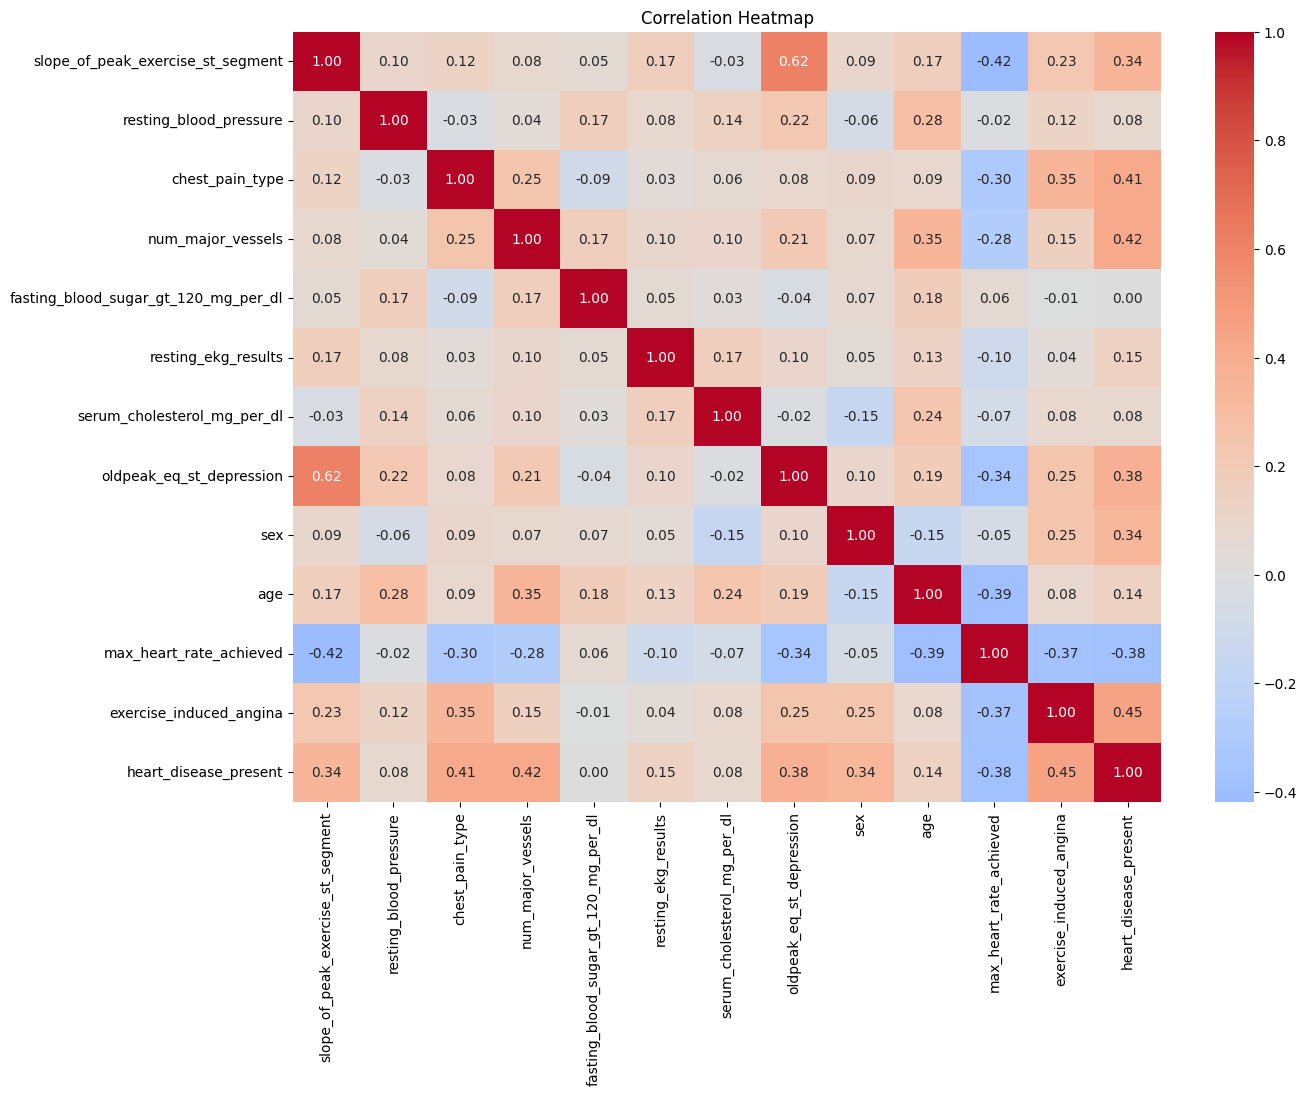

In [23]:
plt.figure(figsize=(14, 10))

sns.heatmap(correlation_matrix,annot=True,fmt=".2f",cmap="coolwarm",center=0)

plt.title("Correlation Heatmap")
plt.show()

In [24]:
target_corr = (
    df[numerical_features + ["heart_disease_present"]]
    .corr()["heart_disease_present"]
    .sort_values(ascending=False)
)

print(target_corr)

heart_disease_present                   1.000000
exercise_induced_angina                 0.448647
num_major_vessels                       0.421519
chest_pain_type                         0.412829
oldpeak_eq_st_depression                0.382930
slope_of_peak_exercise_st_segment       0.344224
sex                                     0.335421
resting_ekg_results                     0.145933
age                                     0.138255
serum_cholesterol_mg_per_dl             0.079775
resting_blood_pressure                  0.078506
fasting_blood_sugar_gt_120_mg_per_dl    0.003379
max_heart_rate_achieved                -0.375352
Name: heart_disease_present, dtype: float64


# Feature vs Target Analysis

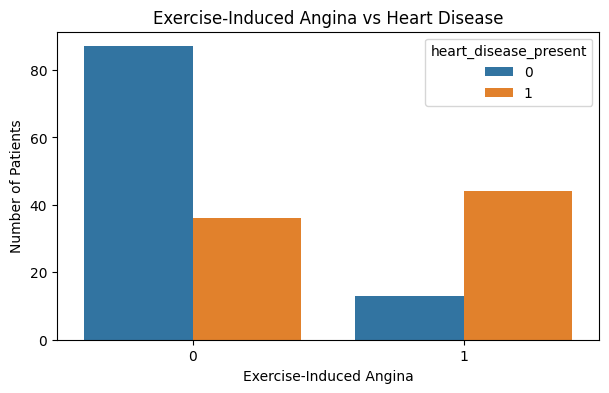

In [25]:
plt.figure(figsize=(7, 4))

sns.countplot(data=df,x="exercise_induced_angina",hue="heart_disease_present")

plt.title("Exercise-Induced Angina vs Heart Disease")
plt.xlabel("Exercise-Induced Angina")
plt.ylabel("Number of Patients")

plt.show()

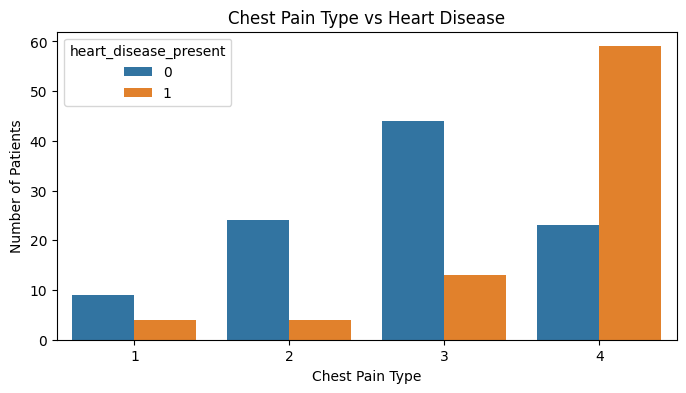

In [26]:
plt.figure(figsize=(8, 4))

sns.countplot(data=df,x="chest_pain_type",hue="heart_disease_present")

plt.title("Chest Pain Type vs Heart Disease")
plt.xlabel("Chest Pain Type")
plt.ylabel("Number of Patients")

plt.show()

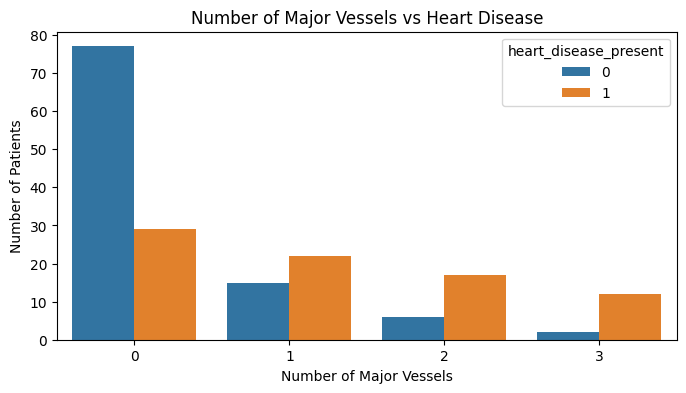

In [27]:
plt.figure(figsize=(8, 4))

sns.countplot(data=df,x="num_major_vessels",hue="heart_disease_present")

plt.title("Number of Major Vessels vs Heart Disease")
plt.xlabel("Number of Major Vessels")
plt.ylabel("Number of Patients")

plt.show()

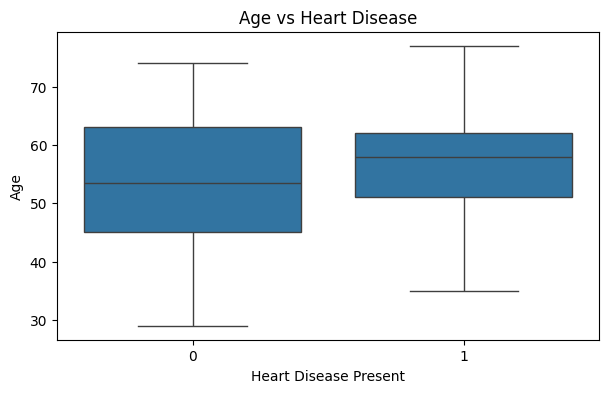

In [28]:
plt.figure(figsize=(7, 4))

sns.boxplot(data=df,x="heart_disease_present",y="age")

plt.title("Age vs Heart Disease")
plt.xlabel("Heart Disease Present")
plt.ylabel("Age")

plt.show()

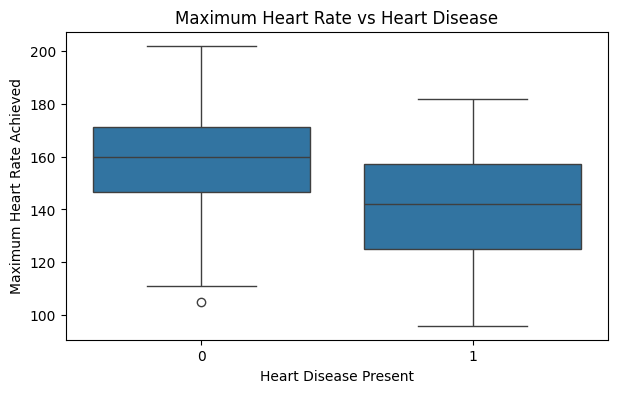

In [29]:
plt.figure(figsize=(7, 4))

sns.boxplot(data=df,x="heart_disease_present",y="max_heart_rate_achieved")

plt.title("Maximum Heart Rate vs Heart Disease")
plt.xlabel("Heart Disease Present")
plt.ylabel("Maximum Heart Rate Achieved")

plt.show()

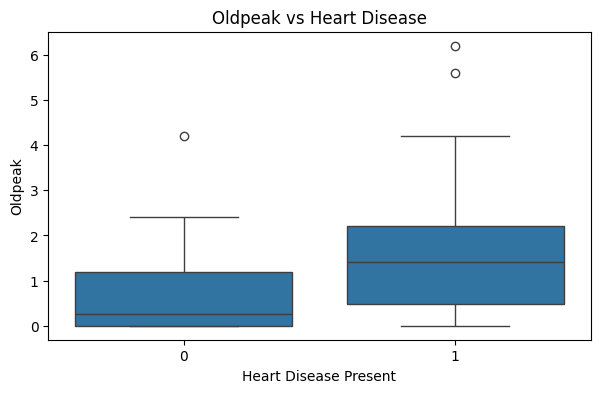

In [30]:
plt.figure(figsize=(7, 4))

sns.boxplot(data=df,x="heart_disease_present",y="oldpeak_eq_st_depression")

plt.title("Oldpeak vs Heart Disease")
plt.xlabel("Heart Disease Present")
plt.ylabel("Oldpeak")

plt.show()

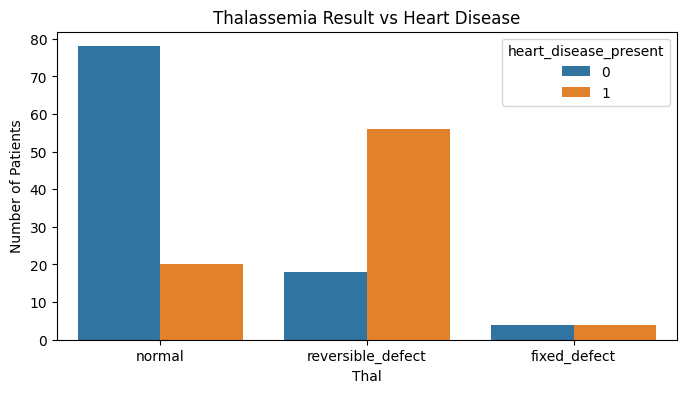

In [31]:
plt.figure(figsize=(8, 4))

sns.countplot(data=df,x="thal",hue="heart_disease_present")

plt.title("Thalassemia Result vs Heart Disease")
plt.xlabel("Thal")
plt.ylabel("Number of Patients")

plt.show()

In [32]:
thal_target = pd.crosstab(df["thal"],df["heart_disease_present"],normalize="index") * 100

print(thal_target)

heart_disease_present          0          1
thal                                       
fixed_defect           50.000000  50.000000
normal                 79.591837  20.408163
reversible_defect      24.324324  75.675676


# EDA Findings

In [33]:
# The dataset contains 180 patient records and 15 columns, including the target variable.

# There are no missing values or duplicate records.

# The target variable contains 100 patients without heart disease and 80 patients with heart disease, making the dataset reasonably balanced.

# thal contains three categories: normal, reversible defect, and fixed defect.
    
# Several variables show potential relationships with heart disease, particularly exercise-induced angina, number of major vessels, chest pain type, oldpeak, and slope of the peak exercise ST segment.

# Maximum heart rate achieved shows a negative relationship with the target.

# Some numerical variables contain potential outliers that require further investigation.

# The patient_id column is an identifier and should not be used as a machine-learning feature.

# The EDA indicates that several clinical variables may contain useful predictive information for the heart disease classification task.

# Data Preprocessing

In [34]:
# create a copy of the dataset
data = df.copy()
data.head()

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0


In [35]:
data = data.drop(columns=["patient_id"])
data.head()

,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
3,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1
4,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0


In [36]:
data.columns

Index(['slope_of_peak_exercise_st_segment', 'thal', 'resting_blood_pressure',
       'chest_pain_type', 'num_major_vessels',
       'fasting_blood_sugar_gt_120_mg_per_dl', 'resting_ekg_results',
       'serum_cholesterol_mg_per_dl', 'oldpeak_eq_st_depression', 'sex', 'age',
       'max_heart_rate_achieved', 'exercise_induced_angina',
       'heart_disease_present'],
      dtype='object')

In [37]:
X = data.drop(columns=["heart_disease_present"])
y = data["heart_disease_present"]

In [38]:
X.shape

(180, 13)

In [39]:
y.shape

(180,)

In [40]:
y.value_counts()

heart_disease_present
0    100
1     80
Name: count, dtype: int64

# identify Categorical and Numerical Features

In [41]:
categorical_features = [
    "thal",
    "sex",
    "chest_pain_type",
    "fasting_blood_sugar_gt_120_mg_per_dl",
    "resting_ekg_results",
    "exercise_induced_angina",
    "slope_of_peak_exercise_st_segment",
    "num_major_vessels"
]

numerical_features = [
    "age",
    "resting_blood_pressure",
    "serum_cholesterol_mg_per_dl",
    "oldpeak_eq_st_depression",
    "max_heart_rate_achieved"
]

In [44]:
X[categorical_features].dtypes

thal                                    object
sex                                      int64
chest_pain_type                          int64
fasting_blood_sugar_gt_120_mg_per_dl     int64
resting_ekg_results                      int64
exercise_induced_angina                  int64
slope_of_peak_exercise_st_segment        int64
num_major_vessels                        int64
dtype: object

In [45]:
X[numerical_features].dtypes

age                              int64
resting_blood_pressure           int64
serum_cholesterol_mg_per_dl      int64
oldpeak_eq_st_depression       float64
max_heart_rate_achieved          int64
dtype: object

In [46]:
for col in categorical_features:
    print(f"\n{col}")
    print(X[col].unique())


thal
['normal' 'reversible_defect' 'fixed_defect']

sex
[1 0]

chest_pain_type
[2 3 4 1]

fasting_blood_sugar_gt_120_mg_per_dl
[0 1]

resting_ekg_results
[2 0 1]

exercise_induced_angina
[0 1]

slope_of_peak_exercise_st_segment
[1 2 3]

num_major_vessels
[0 3 2 1]


# Train-Test Split

In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

In [49]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (144, 13)
X_test : (36, 13)
y_train: (144,)
y_test : (36,)


In [50]:
print("Training target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training target distribution:
heart_disease_present
0    55.555556
1    44.444444
Name: proportion, dtype: float64

Testing target distribution:
heart_disease_present
0    55.555556
1    44.444444
Name: proportion, dtype: float64


# Feature Scaling

In [51]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [52]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore",drop="first"),
            categorical_features
        )
    ]
)

In [53]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

C:\Users\91878\anaconda3\envs\tf_env\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [54]:
print("Processed X_train shape:", X_train_processed.shape)
print("Processed X_test shape :", X_test_processed.shape)

Processed X_train shape: (144, 19)
Processed X_test shape : (36, 19)


In [55]:
feature_names = preprocessor.get_feature_names_out()

print(feature_names)

['num__age' 'num__resting_blood_pressure'
 'num__serum_cholesterol_mg_per_dl' 'num__oldpeak_eq_st_depression'
 'num__max_heart_rate_achieved' 'cat__thal_normal'
 'cat__thal_reversible_defect' 'cat__sex_1' 'cat__chest_pain_type_2'
 'cat__chest_pain_type_3' 'cat__chest_pain_type_4'
 'cat__fasting_blood_sugar_gt_120_mg_per_dl_1'
 'cat__resting_ekg_results_2' 'cat__exercise_induced_angina_1'
 'cat__slope_of_peak_exercise_st_segment_2'
 'cat__slope_of_peak_exercise_st_segment_3' 'cat__num_major_vessels_1'
 'cat__num_major_vessels_2' 'cat__num_major_vessels_3']


# Model Building

In [56]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [57]:
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000,random_state=42))
    ]
)

In [58]:
knn_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ]
)

In [59]:
dt_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(random_state=42))
    ]
)

In [60]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(n_estimators=100,random_state=42))
    ]
)

In [61]:
svm_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", SVC(probability=True,random_state=42))
    ]
)

In [62]:
models = {
    "Logistic Regression": logistic_pipeline,
    "KNN": knn_pipeline,
    "Decision Tree": dt_pipeline,
    "Random Forest": rf_pipeline,
    "SVM": svm_pipeline
}

In [63]:
models

{'Logistic Regression': Pipeline(steps=[('preprocessor',
                  ColumnTransformer(transformers=[('num', StandardScaler(),
                                                   ['age',
                                                    'resting_blood_pressure',
                                                    'serum_cholesterol_mg_per_dl',
                                                    'oldpeak_eq_st_depression',
                                                    'max_heart_rate_achieved']),
                                                  ('cat',
                                                   OneHotEncoder(drop='first',
                                                                 handle_unknown='ignore'),
                                                   ['thal', 'sex',
                                                    'chest_pain_type',
                                                    'fasting_blood_sugar_gt_120_mg_per_dl',
                            

In [64]:
for name, model in models.items():

    model.fit(X_train, y_train)

    print(f"{name} trained successfully.")

Logistic Regression trained successfully.
KNN trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.
SVM trained successfully.


In [67]:
predictions = {}

for name, model in models.items():

    y_pred = model.predict(X_test)

    predictions[name] = y_pred

In [68]:
for name, y_pred in predictions.items():

    accuracy = accuracy_score(y_test, y_pred)

    print(f"{name}: {accuracy:.4f}")

Logistic Regression: 0.8611
KNN: 0.8889
Decision Tree: 0.7222
Random Forest: 0.8333
SVM: 0.8889


In [69]:
results = []

for name, model in models.items():

    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })

In [70]:
results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.861111,0.789474,0.9375,0.857143,0.946875
1,KNN,0.888889,0.833333,0.9375,0.882353,0.959375
2,Decision Tree,0.722222,0.687500,0.6875,0.687500,0.718750
3,Random Forest,0.833333,0.750000,0.9375,0.833333,0.909375
4,SVM,0.888889,0.800000,1.0000,0.888889,0.956250


In [71]:
results_df.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8611,0.7895,0.9375,0.8571,0.9469
1,KNN,0.8889,0.8333,0.9375,0.8824,0.9594
2,Decision Tree,0.7222,0.6875,0.6875,0.6875,0.7188
3,Random Forest,0.8333,0.7500,0.9375,0.8333,0.9094
4,SVM,0.8889,0.8000,1.0000,0.8889,0.9562


In [72]:
results_df.sort_values(by="F1 Score",ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
4,SVM,0.888889,0.800000,1.0000,0.888889,0.956250
1,KNN,0.888889,0.833333,0.9375,0.882353,0.959375
0,Logistic Regression,0.861111,0.789474,0.9375,0.857143,0.946875
3,Random Forest,0.833333,0.750000,0.9375,0.833333,0.909375
2,Decision Tree,0.722222,0.687500,0.6875,0.687500,0.718750


In [73]:
results_df.sort_values(by="Recall",ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
4,SVM,0.888889,0.800000,1.0000,0.888889,0.956250
0,Logistic Regression,0.861111,0.789474,0.9375,0.857143,0.946875
1,KNN,0.888889,0.833333,0.9375,0.882353,0.959375
3,Random Forest,0.833333,0.750000,0.9375,0.833333,0.909375
2,Decision Tree,0.722222,0.687500,0.6875,0.687500,0.718750


In [74]:
results_df.sort_values(by="ROC-AUC",ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
1,KNN,0.888889,0.833333,0.9375,0.882353,0.959375
4,SVM,0.888889,0.800000,1.0000,0.888889,0.956250
0,Logistic Regression,0.861111,0.789474,0.9375,0.857143,0.946875
3,Random Forest,0.833333,0.750000,0.9375,0.833333,0.909375
2,Decision Tree,0.722222,0.687500,0.6875,0.687500,0.718750


# Confusion Matrix

In [76]:
y_pred_lr = models["Logistic Regression"].predict(X_test)

cm = confusion_matrix(y_test, y_pred_lr)

print(cm)

[[16  4]
 [ 1 15]]


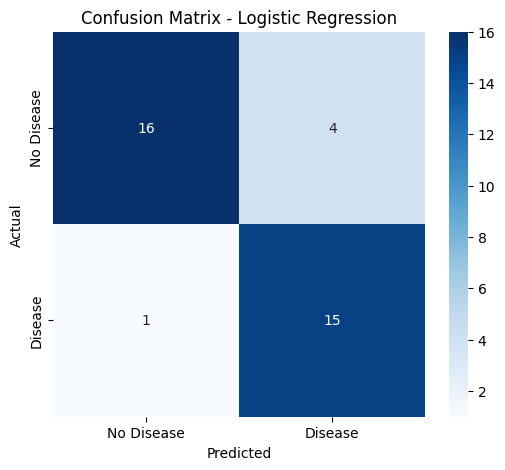

In [77]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

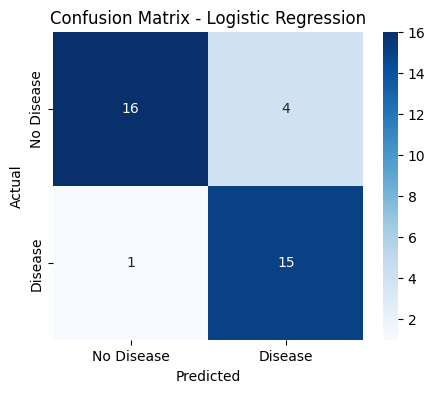

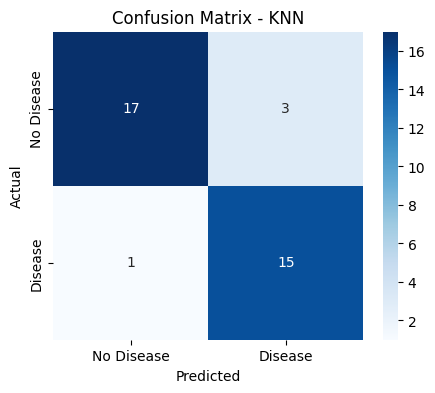

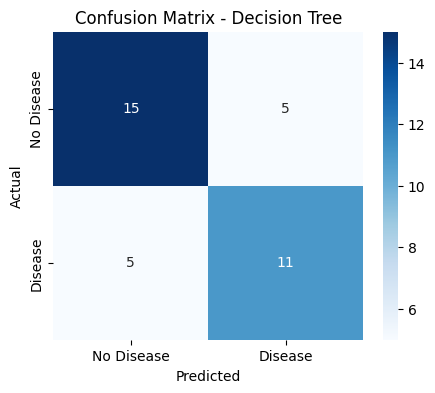

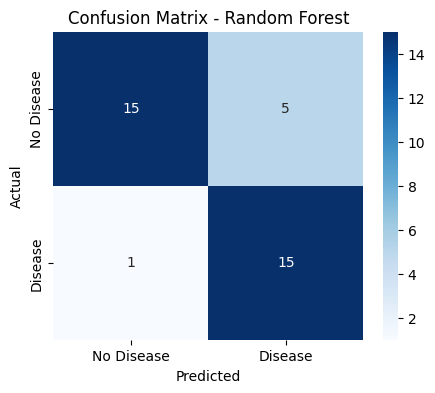

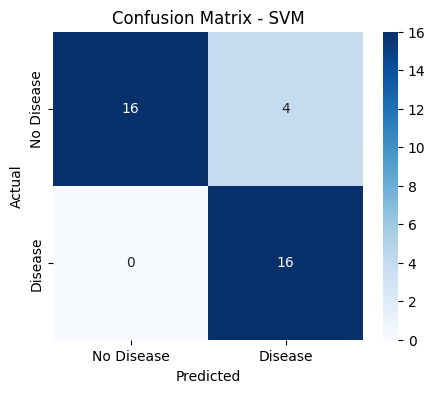

In [78]:
for name, model in models.items():

    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["No Disease", "Disease"],
        yticklabels=["No Disease", "Disease"]
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

# Classification Report

In [80]:
for name, model in models.items():

    y_pred = model.predict(X_test)

    print("=" * 60)
    print(name)
    print("=" * 60)

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=["No Disease", "Disease"]
        )
    )

Logistic Regression
              precision    recall  f1-score   support

  No Disease       0.94      0.80      0.86        20
     Disease       0.79      0.94      0.86        16

    accuracy                           0.86        36
   macro avg       0.87      0.87      0.86        36
weighted avg       0.87      0.86      0.86        36

KNN
              precision    recall  f1-score   support

  No Disease       0.94      0.85      0.89        20
     Disease       0.83      0.94      0.88        16

    accuracy                           0.89        36
   macro avg       0.89      0.89      0.89        36
weighted avg       0.90      0.89      0.89        36

Decision Tree
              precision    recall  f1-score   support

  No Disease       0.75      0.75      0.75        20
     Disease       0.69      0.69      0.69        16

    accuracy                           0.72        36
   macro avg       0.72      0.72      0.72        36
weighted avg       0.72      0.72   

# ROC Curve

In [82]:
from sklearn.metrics import roc_curve

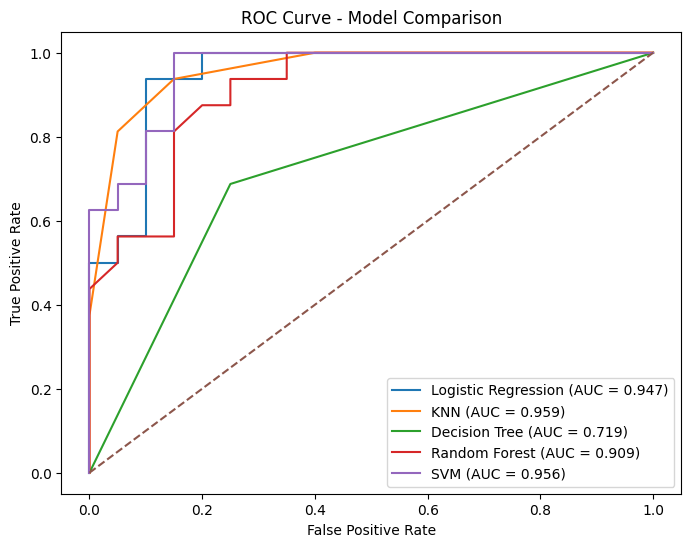

In [83]:
plt.figure(figsize=(8, 6))

for name, model in models.items():

    y_prob = model.predict_proba(X_test)[:, 1]

    fpr, tpr, thresholds = roc_curve(y_test,y_prob)

    auc = roc_auc_score(y_test, y_prob)

    plt.plot(fpr,tpr,label=f"{name} (AUC = {auc:.3f})")

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Model Comparison")

plt.legend()

plt.show()

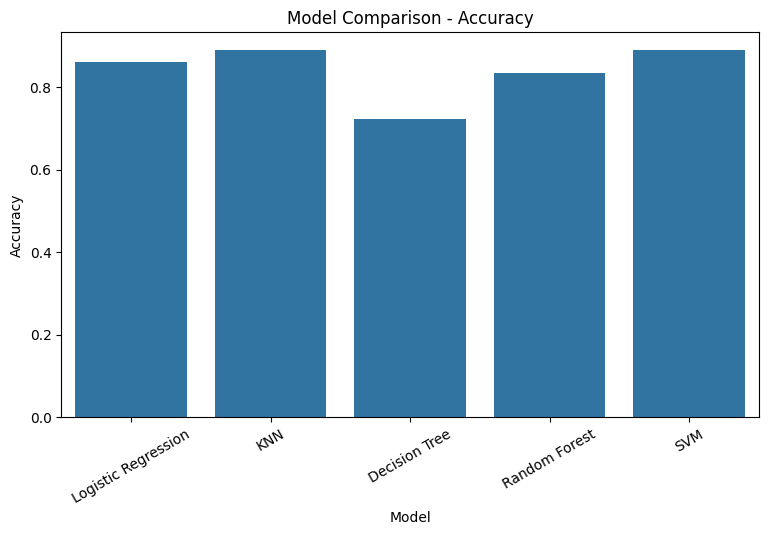

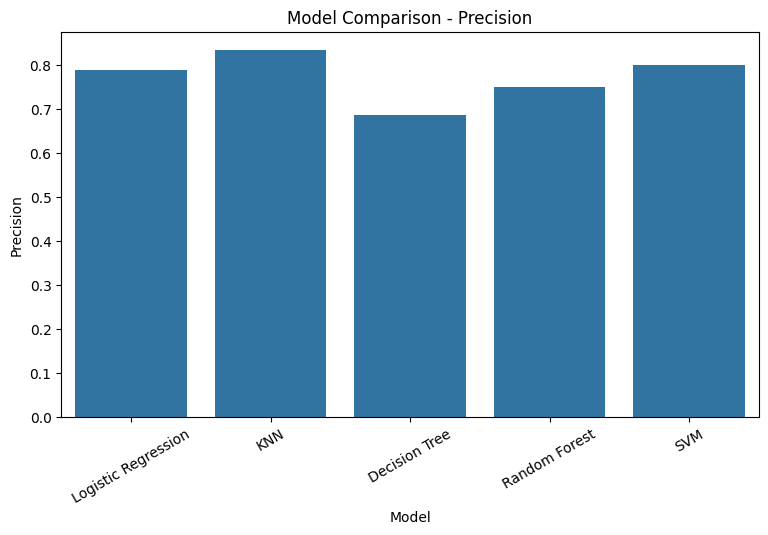

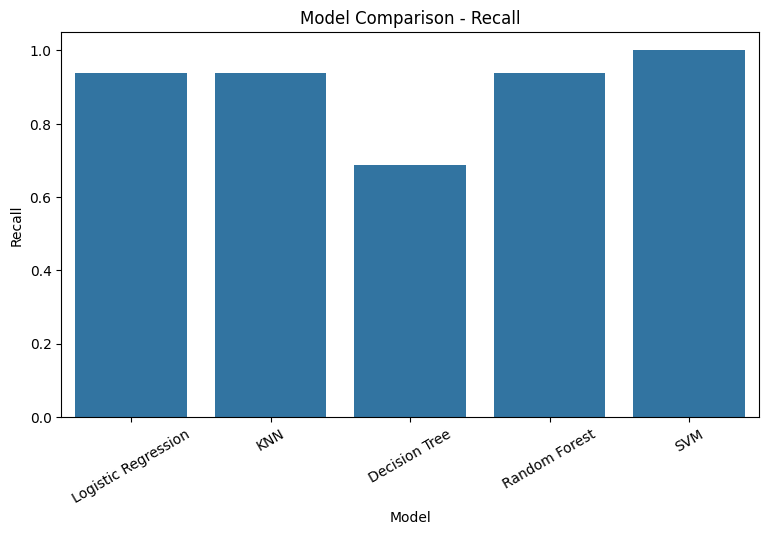

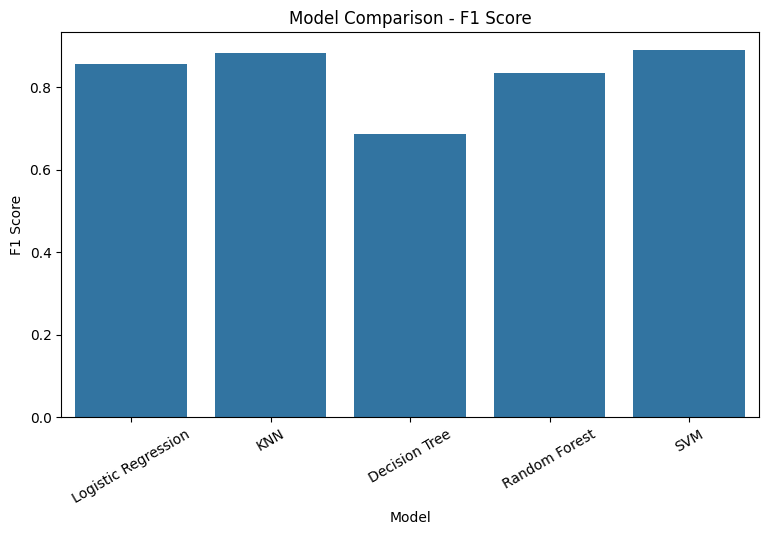

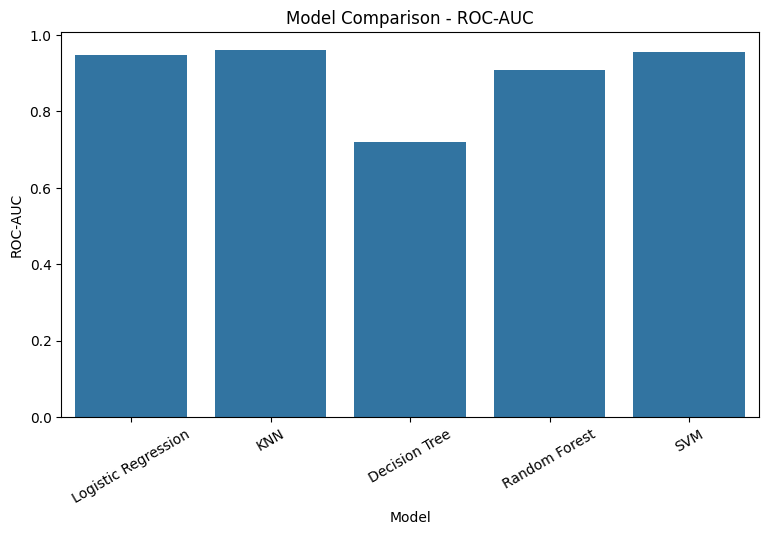

In [84]:
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]

for metric in metrics:

    plt.figure(figsize=(9, 5))

    sns.barplot(data=results_df,x="Model",y=metric)

    plt.title(f"Model Comparison - {metric}")
    plt.xlabel("Model")
    plt.ylabel(metric)

    plt.xticks(rotation=30)

    plt.show()

In [85]:
results_df.to_csv("model_comparison_baseline.csv",index=False)

In [86]:
results_df.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8611,0.7895,0.9375,0.8571,0.9469
1,KNN,0.8889,0.8333,0.9375,0.8824,0.9594
2,Decision Tree,0.7222,0.6875,0.6875,0.6875,0.7188
3,Random Forest,0.8333,0.7500,0.9375,0.8333,0.9094
4,SVM,0.8889,0.8000,1.0000,0.8889,0.9562


# Hyperparameter Tuning & Cross-Validation

In [87]:
from sklearn.model_selection import (StratifiedKFold,GridSearchCV)

In [88]:
cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

In [89]:
scoring = "recall"

In [90]:
logistic_param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__solver": ["liblinear", "lbfgs"]
}

In [91]:
grid_lr = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=logistic_param_grid,
    cv=cv,
    scoring="recall",
    n_jobs=-1
)

In [92]:
grid_lr.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__C': [0.01, 0.1, ...], 'model__solver': ['liblinear', 'lbfgs']}"
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [93]:
print("Best parameters:")
print(grid_lr.best_params_)

Best parameters:
{'model__C': 1, 'model__solver': 'liblinear'}


In [94]:
print("Best CV Recall:")
print(grid_lr.best_score_)

Best CV Recall:
0.7974358974358975


In [96]:
# Tune KNN

In [97]:
knn_param_grid = {
    "model__n_neighbors": [3, 5, 7, 9, 11, 15],
    "model__weights": ["uniform", "distance"],
    "model__metric": ["euclidean", "manhattan"]
}

In [98]:
grid_knn = GridSearchCV(estimator=knn_pipeline,param_grid=knn_param_grid,cv=cv,scoring="recall",n_jobs=-1)

In [99]:
grid_knn.fit(X_train, y_train)

,estimator,Pipeline(step...lassifier())])
,param_grid,"{'model__metric': ['euclidean', 'manhattan'], 'model__n_neighbors': [3, 5, ...], 'model__weights': ['uniform', 'distance']}"
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [100]:
print("Best KNN parameters:")
print(grid_knn.best_params_)

Best KNN parameters:
{'model__metric': 'manhattan', 'model__n_neighbors': 15, 'model__weights': 'uniform'}


In [101]:
print("Best KNN CV Recall:")
print(grid_knn.best_score_)

Best KNN CV Recall:
0.7192307692307692


In [102]:
# Tune SVM

In [103]:
svm_param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__kernel": ["linear", "rbf"],
    "model__gamma": ["scale", "auto"]
}

In [104]:
grid_svm = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=svm_param_grid,
    cv=cv,
    scoring="recall",
    n_jobs=-1
)

In [105]:
grid_svm.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__C': [0.01, 0.1, ...], 'model__gamma': ['scale', 'auto'], 'model__kernel': ['linear', 'rbf']}"
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [106]:
print("Best SVM parameters:")
print(grid_svm.best_params_)

print("Best SVM CV Recall:")
print(grid_svm.best_score_)

Best SVM parameters:
{'model__C': 10, 'model__gamma': 'auto', 'model__kernel': 'rbf'}
Best SVM CV Recall:
0.7512820512820514


In [159]:
#Tune Random Forest

In [108]:
rf_param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 3, 5, 7, 10],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

In [109]:
grid_rf = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    cv=cv,
    scoring="recall",
    n_jobs=-1
)

In [110]:
grid_rf.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__max_depth': [None, 3, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], 'model__n_estimators': [100, 200, ...]}"
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [111]:
print("Best Random Forest parameters:")
print(grid_rf.best_params_)

print("Best Random Forest CV Recall:")
print(grid_rf.best_score_)

Best Random Forest parameters:
{'model__max_depth': 5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Best Random Forest CV Recall:
0.7653846153846156


In [112]:
tuned_models = {
    "Logistic Regression": grid_lr.best_estimator_,
    "KNN": grid_knn.best_estimator_,
    "SVM": grid_svm.best_estimator_,
    "Random Forest": grid_rf.best_estimator_
}

In [113]:
tuned_models

{'Logistic Regression': Pipeline(steps=[('preprocessor',
                  ColumnTransformer(transformers=[('num', StandardScaler(),
                                                   ['age',
                                                    'resting_blood_pressure',
                                                    'serum_cholesterol_mg_per_dl',
                                                    'oldpeak_eq_st_depression',
                                                    'max_heart_rate_achieved']),
                                                  ('cat',
                                                   OneHotEncoder(drop='first',
                                                                 handle_unknown='ignore'),
                                                   ['thal', 'sex',
                                                    'chest_pain_type',
                                                    'fasting_blood_sugar_gt_120_mg_per_dl',
                            

In [114]:
tuned_results = []

for name, model in tuned_models.items():

    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    tuned_results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })

In [115]:
tuned_results_df = pd.DataFrame(tuned_results)

tuned_results_df.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8611,0.7619,1.0000,0.8649,0.9375
1,KNN,0.8889,0.8333,0.9375,0.8824,0.9188
2,SVM,0.8056,0.7143,0.9375,0.8108,0.9625
3,Random Forest,0.8333,0.7778,0.8750,0.8235,0.9250


# Compare Baseline vs Tuned

In [117]:
print("BASELINE RESULTS")
display(results_df.round(4))

print("\nTUNED RESULTS")
display(tuned_results_df.round(4))

BASELINE RESULTS


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8611,0.7895,0.9375,0.8571,0.9469
1,KNN,0.8889,0.8333,0.9375,0.8824,0.9594
2,Decision Tree,0.7222,0.6875,0.6875,0.6875,0.7188
3,Random Forest,0.8333,0.7500,0.9375,0.8333,0.9094
4,SVM,0.8889,0.8000,1.0000,0.8889,0.9562



TUNED RESULTS


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8611,0.7619,1.0000,0.8649,0.9375
1,KNN,0.8889,0.8333,0.9375,0.8824,0.9188
2,SVM,0.8056,0.7143,0.9375,0.8108,0.9625
3,Random Forest,0.8333,0.7778,0.8750,0.8235,0.9250


In [118]:
lr_cv_results = pd.DataFrame(grid_lr.cv_results_)

lr_cv_results[
    [
        "params",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].sort_values("rank_test_score").head(10)

,params,mean_test_score,std_test_score,rank_test_score
4,"{'model__C': 1, 'model__solver': 'liblinear'}",0.797436,0.091161,1
5,"{'model__C': 1, 'model__solver': 'lbfgs'}",0.766667,0.107080,2
2,"{'model__C': 0.1, 'model__solver': 'liblinear'}",0.765385,0.069231,3
6,"{'model__C': 10, 'model__solver': 'liblinear'}",0.751282,0.111059,4
7,"{'model__C': 10, 'model__solver': 'lbfgs'}",0.751282,0.111059,4
8,"{'model__C': 100, 'model__solver': 'liblinear'}",0.751282,0.111059,4
9,"{'model__C': 100, 'model__solver': 'lbfgs'}",0.751282,0.111059,4
3,"{'model__C': 0.1, 'model__solver': 'lbfgs'}",0.733333,0.095390,8
0,"{'model__C': 0.01, 'model__solver': 'liblinear'}",0.703846,0.111206,9
1,"{'model__C': 0.01, 'model__solver': 'lbfgs'}",0.500000,0.103203,10


In [119]:
knn_cv_results = pd.DataFrame(grid_knn.cv_results_)

knn_cv_results[
    [
        "params",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].sort_values("rank_test_score").head(10)

,params,mean_test_score,std_test_score,rank_test_score
23,"{'model__metric': 'manhattan', 'model__n_neigh...",0.719231,0.090691,1
22,"{'model__metric': 'manhattan', 'model__n_neigh...",0.719231,0.090691,1
6,"{'model__metric': 'euclidean', 'model__n_neigh...",0.703846,0.111206,3
7,"{'model__metric': 'euclidean', 'model__n_neigh...",0.703846,0.111206,3
17,"{'model__metric': 'manhattan', 'model__n_neigh...",0.703846,0.111206,3
21,"{'model__metric': 'manhattan', 'model__n_neigh...",0.702564,0.059805,6
12,"{'model__metric': 'manhattan', 'model__n_neigh...",0.702564,0.114211,7
13,"{'model__metric': 'manhattan', 'model__n_neigh...",0.702564,0.114211,7
10,"{'model__metric': 'euclidean', 'model__n_neigh...",0.688462,0.064817,9
11,"{'model__metric': 'euclidean', 'model__n_neigh...",0.688462,0.064817,9


In [120]:
svm_cv_results = pd.DataFrame(grid_svm.cv_results_)

svm_cv_results[
    [
        "params",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].sort_values("rank_test_score").head(10)

,params,mean_test_score,std_test_score,rank_test_score
15,"{'model__C': 10, 'model__gamma': 'auto', 'mode...",0.751282,0.111059,1
6,"{'model__C': 0.1, 'model__gamma': 'auto', 'mod...",0.750000,0.089377,2
9,"{'model__C': 1, 'model__gamma': 'scale', 'mode...",0.750000,0.101760,2
4,"{'model__C': 0.1, 'model__gamma': 'scale', 'mo...",0.750000,0.089377,2
19,"{'model__C': 100, 'model__gamma': 'auto', 'mod...",0.735897,0.122863,5
16,"{'model__C': 100, 'model__gamma': 'scale', 'mo...",0.735897,0.089413,6
18,"{'model__C': 100, 'model__gamma': 'auto', 'mod...",0.735897,0.089413,6
8,"{'model__C': 1, 'model__gamma': 'scale', 'mode...",0.734615,0.103489,8
10,"{'model__C': 1, 'model__gamma': 'auto', 'model...",0.734615,0.103489,8
17,"{'model__C': 100, 'model__gamma': 'scale', 'mo...",0.720513,0.140535,10


In [121]:
rf_cv_results = pd.DataFrame(grid_rf.cv_results_)

rf_cv_results[
    [
        "params",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].sort_values("rank_test_score").head(10)

,params,mean_test_score,std_test_score,rank_test_score
54,"{'model__max_depth': 5, 'model__min_samples_le...",0.765385,0.084615,1
0,"{'model__max_depth': None, 'model__min_samples...",0.750000,0.101760,2
14,"{'model__max_depth': None, 'model__min_samples...",0.750000,0.101760,2
11,"{'model__max_depth': None, 'model__min_samples...",0.750000,0.101760,2
57,"{'model__max_depth': 5, 'model__min_samples_le...",0.750000,0.101760,2
59,"{'model__max_depth': 5, 'model__min_samples_le...",0.750000,0.101760,2
56,"{'model__max_depth': 5, 'model__min_samples_le...",0.750000,0.101760,2
55,"{'model__max_depth': 5, 'model__min_samples_le...",0.750000,0.101760,2
61,"{'model__max_depth': 5, 'model__min_samples_le...",0.750000,0.057048,2
108,"{'model__max_depth': 10, 'model__min_samples_l...",0.750000,0.101760,2


# Compare Models by Recall

In [124]:
tuned_results_df.sort_values(by="Recall",ascending=False).round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8611,0.7619,1.0000,0.8649,0.9375
1,KNN,0.8889,0.8333,0.9375,0.8824,0.9188
2,SVM,0.8056,0.7143,0.9375,0.8108,0.9625
3,Random Forest,0.8333,0.7778,0.8750,0.8235,0.9250


# Compare Models by F1

In [127]:
tuned_results_df.sort_values(by="F1 Score",ascending=False).round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
1,KNN,0.8889,0.8333,0.9375,0.8824,0.9188
0,Logistic Regression,0.8611,0.7619,1.0000,0.8649,0.9375
3,Random Forest,0.8333,0.7778,0.8750,0.8235,0.9250
2,SVM,0.8056,0.7143,0.9375,0.8108,0.9625


# Compare Models by ROC-AUC

In [128]:
tuned_results_df.sort_values(by="ROC-AUC",ascending=False).round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,SVM,0.8056,0.7143,0.9375,0.8108,0.9625
0,Logistic Regression,0.8611,0.7619,1.0000,0.8649,0.9375
3,Random Forest,0.8333,0.7778,0.8750,0.8235,0.9250
1,KNN,0.8889,0.8333,0.9375,0.8824,0.9188


In [129]:
tuned_results_df.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8611,0.7619,1.0000,0.8649,0.9375
1,KNN,0.8889,0.8333,0.9375,0.8824,0.9188
2,SVM,0.8056,0.7143,0.9375,0.8108,0.9625
3,Random Forest,0.8333,0.7778,0.8750,0.8235,0.9250


In [130]:
print("Logistic Regression:", grid_lr.best_params_, grid_lr.best_score_)
print("KNN:", grid_knn.best_params_, grid_knn.best_score_)
print("SVM:", grid_svm.best_params_, grid_svm.best_score_)
print("Random Forest:", grid_rf.best_params_, grid_rf.best_score_)

Logistic Regression: {'model__C': 1, 'model__solver': 'liblinear'} 0.7974358974358975
KNN: {'model__metric': 'manhattan', 'model__n_neighbors': 15, 'model__weights': 'uniform'} 0.7192307692307692
SVM: {'model__C': 10, 'model__gamma': 'auto', 'model__kernel': 'rbf'} 0.7512820512820514
Random Forest: {'model__max_depth': 5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 100} 0.7653846153846156


In [131]:
from sklearn.model_selection import cross_validate

scoring_metrics = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

In [132]:
cv_results = []

for name, model in tuned_models.items():

    scores = cross_validate(model,X_train,y_train,cv=cv,scoring=scoring_metrics,n_jobs=-1)

    cv_results.append({
        "Model": name,

        "CV Accuracy Mean":
            scores["test_accuracy"].mean(),

        "CV Precision Mean":
            scores["test_precision"].mean(),

        "CV Recall Mean":
            scores["test_recall"].mean(),

        "CV F1 Mean":
            scores["test_f1"].mean(),

        "CV ROC-AUC Mean":
            scores["test_roc_auc"].mean(),

        "CV Accuracy Std":
            scores["test_accuracy"].std(),

        "CV Recall Std":
            scores["test_recall"].std(),

        "CV F1 Std":
            scores["test_f1"].std(),

        "CV ROC-AUC Std":
            scores["test_roc_auc"].std()
    })

In [133]:
cv_results_df = pd.DataFrame(cv_results)

cv_results_df.round(4)

,Model,CV Accuracy Mean,CV Precision Mean,CV Recall Mean,CV F1 Mean,CV ROC-AUC Mean,CV Accuracy Std,CV Recall Std,CV F1 Std,CV ROC-AUC Std
0,Logistic Regression,0.8131,0.8036,0.7974,0.7945,0.8534,0.0826,0.0912,0.0860,0.0654
1,KNN,0.8054,0.8271,0.7192,0.7651,0.8835,0.0521,0.0907,0.0682,0.0502
2,SVM,0.7431,0.7124,0.7513,0.7209,0.8265,0.0347,0.1111,0.0291,0.0819
3,Random Forest,0.7990,0.8018,0.7654,0.7748,0.8631,0.0660,0.0846,0.0643,0.0730


In [134]:
cv_results_df.round(4)

,Model,CV Accuracy Mean,CV Precision Mean,CV Recall Mean,CV F1 Mean,CV ROC-AUC Mean,CV Accuracy Std,CV Recall Std,CV F1 Std,CV ROC-AUC Std
0,Logistic Regression,0.8131,0.8036,0.7974,0.7945,0.8534,0.0826,0.0912,0.0860,0.0654
1,KNN,0.8054,0.8271,0.7192,0.7651,0.8835,0.0521,0.0907,0.0682,0.0502
2,SVM,0.7431,0.7124,0.7513,0.7209,0.8265,0.0347,0.1111,0.0291,0.0819
3,Random Forest,0.7990,0.8018,0.7654,0.7748,0.8631,0.0660,0.0846,0.0643,0.0730


The selected Logistic Regression model is recommended as the production candidate for this project based on its cross-validation performance and balance between recall, precision and F1-score. However, the model should be considered a decision-support prototype rather than a clinical diagnostic system. Further validation using larger and independent clinical datasets would be required before real-world deployment.

# Train Final Model 

In [136]:
grid_lr.best_estimator_

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [137]:
final_model = grid_lr.best_estimator_

In [138]:
print(final_model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age',
                                                   'resting_blood_pressure',
                                                   'serum_cholesterol_mg_per_dl',
                                                   'oldpeak_eq_st_depression',
                                                   'max_heart_rate_achieved']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['thal', 'sex',
                                                   'chest_pain_type',
                                                   'fasting_blood_sugar_gt_120_mg_per_dl',
                                                   'resting_ekg_

In [139]:
final_predictions = final_model.predict(X_test)

final_probabilities = final_model.predict_proba(X_test)[:, 1]

In [140]:
final_accuracy = accuracy_score(
    y_test,
    final_predictions
)

final_precision = precision_score(
    y_test,
    final_predictions
)

final_recall = recall_score(
    y_test,
    final_predictions
)

final_f1 = f1_score(
    y_test,
    final_predictions
)

final_roc_auc = roc_auc_score(
    y_test,
    final_probabilities
)

In [141]:
print(f"Accuracy : {final_accuracy:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall   : {final_recall:.4f}")
print(f"F1 Score : {final_f1:.4f}")
print(f"ROC-AUC  : {final_roc_auc:.4f}")

Accuracy : 0.8611
Precision: 0.7619
Recall   : 1.0000
F1 Score : 0.8649
ROC-AUC  : 0.9375


In [142]:
final_cm = confusion_matrix(
    y_test,
    final_predictions
)

print(final_cm)

[[15  5]
 [ 0 16]]


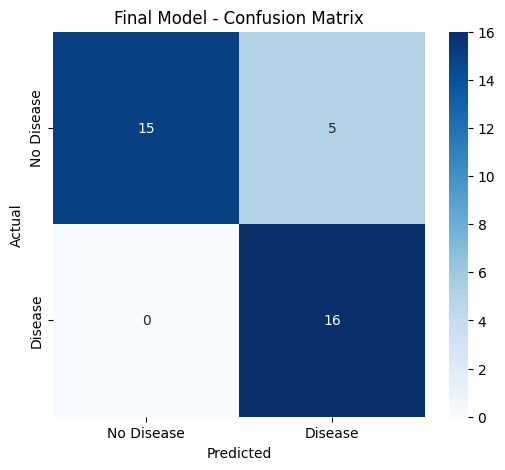

In [143]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)

plt.title("Final Model - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [144]:
print(classification_report(y_test,final_predictions,target_names=["No Disease","Disease"]))

              precision    recall  f1-score   support

  No Disease       1.00      0.75      0.86        20
     Disease       0.76      1.00      0.86        16

    accuracy                           0.86        36
   macro avg       0.88      0.88      0.86        36
weighted avg       0.89      0.86      0.86        36



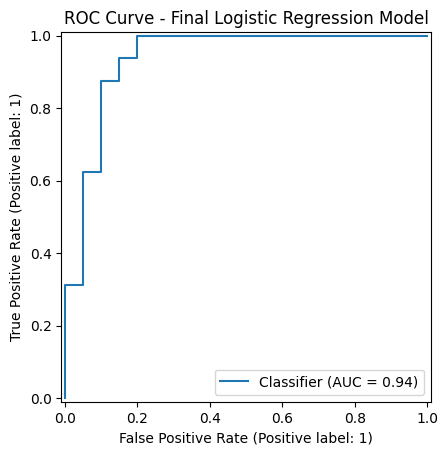

In [145]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    final_probabilities
)

plt.title("ROC Curve - Final Logistic Regression Model")
plt.show()

In [146]:
lr_model = final_model.named_steps["model"]

In [147]:
preprocessor_final = final_model.named_steps["preprocessor"]

In [148]:
feature_names = preprocessor_final.get_feature_names_out()

In [149]:
coefficients = lr_model.coef_[0]

In [150]:
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

In [151]:
feature_importance_df["Absolute_Coefficient"] = (
    feature_importance_df["Coefficient"].abs()
)

feature_importance_df = feature_importance_df.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

feature_importance_df.head(15)

,Feature,Coefficient,Absolute_Coefficient
5,cat__thal_normal,-1.052083,1.052083
17,cat__num_major_vessels_2,0.936008,0.936008
18,cat__num_major_vessels_3,0.923826,0.923826
10,cat__chest_pain_type_4,0.845096,0.845096
7,cat__sex_1,0.769729,0.769729
16,cat__num_major_vessels_1,0.632172,0.632172
12,cat__resting_ekg_results_2,0.607813,0.607813
6,cat__thal_reversible_defect,0.567260,0.567260
13,cat__exercise_induced_angina_1,0.446266,0.446266
3,num__oldpeak_eq_st_depression,0.431330,0.431330


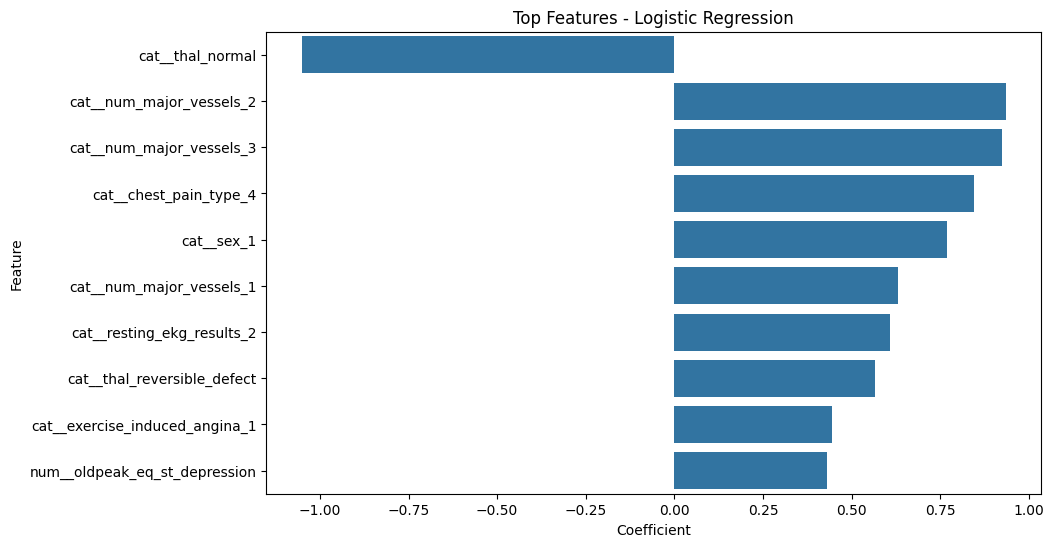

In [152]:
top_features = feature_importance_df.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x="Coefficient",
    y="Feature"
)

plt.title("Top Features - Logistic Regression")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.show()

# Save The Final Model

In [153]:
import joblib

joblib.dump(final_model,"heart_disease_final_model.pkl")

['heart_disease_final_model.pkl']

In [154]:
import os

print("Model saved:",os.path.exists("heart_disease_final_model.pkl"))

Model saved: True


Logistic Regression was selected as the final production candidate based on its overall cross-validation performance, particularly its recall and F1-score, combined with strong test-set performance and interpretability. KNN was identified as a strong alternative due to its higher cross-validation ROC-AUC.

# Hospital Recommendations

## 1 : Early Risk Screening

The trained Logistic Regression model can be used as a decision-support
tool to identify patients who may require further clinical evaluation.

Final test performance:
- Accuracy: 86.11%
- Precision: 76.19%
- Recall: 100%
- F1 Score: 86.49%
- ROC-AUC: 93.75%

## 2 : High-Risk Patient Prioritization
The hospital can use the model's prediction probability to help prioritize patients for further assessment.

- Patient Data
     ↓
- ML Prediction
     ↓
- Risk Screening
     ↓
 ┌───────────────┐
 │ Higher Risk?  │
 └───────┬───────┘
         ↓
- Further Clinical Evaluation
         ↓
- Doctor's Assessment
         ↓
- Treatment / Prevention Plan

## 3 : Collect Important Patient Information

- Age
- Sex
- Resting blood pressure
- Serum cholesterol
- Chest pain type
- Maximum heart rate achieved
- Exercise-induced angina
- Resting ECG results
- ST-segment depression (oldpeak)
- Number of major vessels
- Thallium stress-test result
- Fasting blood sugar
- Exercise ST-segment slope

## 4 : Give Special Attention to High-Risk Predictions

If the model predicts a patient as potentially having heart disease, the hospital can flag that patient for additional clinical evaluation.

## 5 : Reduce False Negatives
Hospitals should continue monitoring recall/sensitivity because missing a potentially high-risk patient can be more concerning than sending a low-risk patient for additional evaluation.

## 6 : Regularly Monitor Model Performance

If the model were ever used operationally, hospitals should periodically evaluate:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- False positives
- False negatives

## 7 : Use the Model Alongside Clinical Expertise

ML prediction + patient history + clinical examination + appropriate diagnostic evaluation = final clinical decision

## 8 : Preventive Health Recommendations

For patients identified as potentially high risk, the hospital can encourage appropriate preventive care and follow-up based on the clinician's assessment.

Examples include:

- Regular health check-ups
- Monitoring blood pressure
- Monitoring cholesterol
- Monitoring blood glucose
- Maintaining appropriate physical activity
- Maintaining a healthy diet
- Avoiding tobacco use
- Maintaining a healthy body weight
- Following prescribed treatment
- Attending scheduled follow-up appointments

## 9 :  Hospital Implementation Recommendation 

                 PATIENT
                    │
                    ↓
          Collect Patient Data
                    │
                    ↓
        Data Preprocessing Pipeline
                    │
                    ↓
       Logistic Regression Model
                    │
                    ↓
        Potential Risk Prediction
              /           \
             /             \
       Lower Risk        Higher Risk
          │                  │
          ↓                  ↓
   Routine Follow-up   Clinical Review
                           │
                           ↓
                    Further Evaluation
                           │
                           ↓
                  Preventive / Treatment
                        Planning

##  Suggestions to the Hospital for Early Detection and Prevention of Heart Disease

The developed machine learning model can be used as a decision-support tool to help hospitals identify patients who may require further evaluation for potential heart disease. The final Logistic Regression model achieved 86.11% accuracy, 76.19% precision, 100% recall, 86.49% F1-score and 93.75% ROC-AUC on the test dataset. The confusion matrix contained 15 true negatives, 5 false positives, 0 false negatives and 16 true positives.

Hospitals can use such a model for early risk screening and prioritization of patients for further clinical assessment. Relevant patient information such as age, blood pressure, cholesterol, chest pain type, ECG results, maximum heart rate, exercise-induced angina, ST-segment measurements, number of major vessels and thallium-test results should be accurately collected because these variables are included in the project dataset.

Patients receiving a positive or higher-risk prediction should be referred for appropriate clinical evaluation rather than being diagnosed solely by the machine learning model. The model should support doctors and healthcare professionals in making informed decisions, while the final diagnosis and treatment plan should remain based on clinical assessment and appropriate medical testing.

Hospitals should also monitor model performance regularly using metrics such as recall, precision, F1-score, ROC-AUC, false positives and false negatives. Particular attention should be given to false negatives because they represent potentially affected patients who were not identified by the model.

Preventive healthcare programs can also focus on appropriate monitoring of blood pressure, cholesterol and blood glucose, regular health check-ups, physical activity, healthy dietary habits, tobacco avoidance, weight management and timely follow-up according to individual clinical needs.

Finally, the model should be considered a prototype decision-support system rather than a clinically validated diagnostic tool. The dataset used in this project is relatively small, so further validation on larger and independent patient datasets would be necessary before considering real-world clinical deployment.


## Model Comparison Report

##  Baseline Model Comparison

| Model               |   Accuracy |  Precision |      Recall |   F1 Score |    ROC-AUC |
| ------------------- | ---------: | ---------: | ----------: | ---------: | ---------: |
| Logistic Regression |     86.11% |     78.95% |      93.75% |     85.71% |     94.69% |
| **KNN**             | **88.89%** | **83.33%** |      93.75% | **88.24%** | **95.94%** |
| Decision Tree       |     72.22% |     68.75% |      68.75% |     68.75% |     71.88% |
| Random Forest       |     83.33% |     75.00% |      93.75% |     83.33% |     90.94% |
| **SVM**             | **88.89%** |     80.00% | **100.00%** | **88.89%** |     95.62% |


## Tuned Model Comparison

| Model               |   Accuracy |  Precision |      Recall |   F1 Score |    ROC-AUC |
| ------------------- | ---------: | ---------: | ----------: | ---------: | ---------: |
| Logistic Regression |     86.11% |     76.19% | **100.00%** |     86.49% |     93.75% |
| **KNN**             | **88.89%** | **83.33%** |      93.75% | **88.24%** |     91.88% |
| SVM                 |     80.56% |     71.43% |      93.75% |     81.08% | **96.25%** |
| Random Forest       |     83.33% |     77.78% |      87.50% |     82.35% |     92.50% |


## Cross-Validation Comparison

| Model                   | CV Accuracy | CV Precision |  CV Recall |      CV F1 | CV ROC-AUC |
| ----------------------- | ----------: | -----------: | ---------: | ---------: | ---------: |
| **Logistic Regression** |  **81.31%** |       80.36% | **79.74%** | **79.45%** |     85.34% |
| KNN                     |      80.54% |   **82.71%** |     71.92% |     76.51% | **88.35%** |
| SVM                     |      74.31% |       71.24% |     75.13% |     72.09% |     82.65% |
| Random Forest           |      79.90% |       80.18% |     76.54% |     77.48% |     86.31% |


## Final Model Selection

Based on the cross-validation results and the final test-set evaluation, we select:

 **Logistic Regression**

The reason is not simply that it has the highest accuracy.

The important points are:

**Cross-validation**
- CV Accuracy = 81.31%
- CV Recall   = 79.74%
- CV F1       = 79.45% 

**Final test set**
- Accuracy  = 86.11%
- Precision = 76.19%
- Recall    = 100.00%
- F1        = 86.49%
- ROC-AUC   = 93.75%

**Confusion Matrix**
[[15  5]
 [ 0 16]]
 
**The model produced:**

- True Negative  = 15
- False Positive = 5
- False Negative = 0
- True Positive  = 16

## Model Comparison Report

Five machine learning algorithms were evaluated for the heart disease prediction problem: Logistic Regression, K-Nearest Neighbors (KNN), Decision Tree, Random Forest and Support Vector Machine (SVM).

The baseline evaluation showed that KNN and SVM achieved the highest accuracy of 88.89%. SVM achieved the highest recall of 100%, while KNN achieved the highest precision of 83.33% and ROC-AUC of 95.94% among the baseline models. Decision Tree showed the weakest performance with an accuracy of 72.22%.

Hyperparameter tuning was then performed for Logistic Regression, KNN, SVM and Random Forest using 5-fold Stratified Cross-Validation. The tuned models were evaluated using accuracy, precision, recall, F1-score and ROC-AUC.

Cross-validation showed that Logistic Regression achieved the highest mean accuracy (81.31%), recall (79.74%) and F1-score (79.45%) among the tuned models. KNN achieved the highest mean precision (82.71%) and ROC-AUC (88.35%). Although SVM achieved a test-set ROC-AUC of 96.25%, its cross-validation performance was lower than the other leading models.

Based on the overall cross-validation performance, recall, F1-score, test-set performance and model interpretability, Logistic Regression was selected as the final production candidate for this project.

The final Logistic Regression model achieved 86.11% accuracy, 76.19% precision, 100% recall, 86.49% F1-score and 93.75% ROC-AUC on the test set. Its confusion matrix contained 15 true negatives, 5 false positives, 0 false negatives and 16 true positives.

The model is recommended as a decision-support prototype for identifying patients who may require further clinical evaluation. It should not be considered a standalone diagnostic system. Further validation using larger and independent clinical datasets would be necessary before real-world clinical deployment.


## Challenges Faced & Techniques Used

| Challenge                            | Technique Used                   | Reason                                      |
| ------------------------------------ | -------------------------------- | ------------------------------------------- |
| Understanding the dataset            | EDA                              | Understand data structure and patterns      |
| Categorical variables                | One-Hot Encoding                 | Convert categories into numerical features  |
| Different feature scales             | Feature Scaling                  | Put numerical features on comparable scales |
| Avoiding data leakage                | Pipeline                         | Keep preprocessing and modeling together    |
| Model selection                      | Multiple ML algorithms           | Compare different approaches                |
| Model improvement                    | GridSearchCV                     | Find better hyperparameters                 |
| Small dataset                        | Stratified K-Fold CV             | Obtain more reliable performance estimates  |
| Class imbalance/performance concerns | Precision, Recall, F1            | Evaluate beyond accuracy                    |
| Prediction errors                    | Confusion Matrix                 | Analyze TP, TN, FP and FN                   |
| Model interpretation                 | Logistic Regression coefficients | Understand feature contributions            |
| Final model selection                | Multi-metric comparison          | Select model using several criteria         |
| Medical deployment concerns          | Responsible interpretation       | Avoid treating prototype as a diagnosis     |


During the development of the heart disease prediction model, several
challenges were encountered. The dataset contained both numerical and
categorical variables, requiring appropriate preprocessing before model
training.

Exploratory Data Analysis (EDA) was performed to understand the dataset,
identify patterns, inspect distributions and examine the target variable.
Categorical variables were converted into numerical representations using
One-Hot Encoding, while numerical variables were scaled as part of the
preprocessing pipeline.

A machine-learning pipeline was used to combine preprocessing and model
training and help prevent data leakage. Multiple classification algorithms,
including Logistic Regression, KNN, Decision Tree, Random Forest and SVM,
were evaluated to identify a suitable model.

Hyperparameter tuning was performed using GridSearchCV for Logistic
Regression, KNN, SVM and Random Forest. Stratified K-Fold Cross-Validation
was then used to obtain a more reliable estimate of model performance because
the dataset is relatively small.

Several evaluation metrics were considered, including accuracy, precision,
recall, F1-score and ROC-AUC. Confusion matrices were also used to examine
true positives, true negatives, false positives and false negatives. The
final Logistic Regression model achieved 100% recall on the test set, with
0 false negatives and 5 false positives.

Logistic Regression coefficients were analyzed to understand the relative
contribution of the encoded features to the model predictions. The final
model was selected using a combination of cross-validation performance,
recall, F1-score, test-set performance and interpretability rather than
relying on a single metric.

Finally, because this project uses a relatively small dataset, the model
should be considered a decision-support prototype rather than a standalone
clinical diagnostic system. Further validation using larger and independent
clinical datasets would be required before real-world deployment.